____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [62]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter']),
 dict_keys(['swot250naive', 'swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']),
 dict_keys(['era5']))

_______
# Surface

In [57]:
dt = 2
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5',wd_model='rio', ggd_var='etac', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5',wd_model='rio', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', wd_model='rio',ggd_var='etac', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', wd_model='rio',ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5',wd_model='rio', ggd_var='adt', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5',wd_model='rio', ggd_var='adt', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5',wd_model='rio', ggd_var='adt', wd_depth='0'),
]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)

# Closure figs
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()

df['Pressure gradient'] = ['L3-250m-SWOT-unfiltered', 'L3-250m-SWOT-filtered', 'L3-2km-SWOT-unfiltered','L3-2km-SWOT-filtered','L4-SWOT','L4-regional-noSWOT','L4-global-noSWOT',]
df = df.reset_index().set_index('Pressure gradient')






nofilter___swot250naive_etac__rio_0era5
nofilter___swot250naive_etaf__rio_0era5
nofilter___swot2kmnaive_etac__rio_0era5
nofilter___swot2kmnaive_etaf__rio_0era5
nofilter___L4withswot_adt__rio_0era5
nofilter___L4noswotregional_adt__rio_0era5
nofilter___L4noswotglobal_adt__rio_0era5
Identified SWOT and drifter outliers have been removed


In [58]:
DSS

<xarray.Dataset> Size: 56MB
Dimensions:        (id_comb: 7, row_number: 24998)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 1MB 2023-04-01T21:50:...
    longitude      (id_comb, row_number) float64 1MB 5.609 5.611 ... 1.926 1.926
    latitude       (id_comb, row_number) float64 1MB 42.28 42.28 ... 38.62 38.62
    pass_number    (id_comb, row_number) float64 1MB 3.0 3.0 3.0 ... 16.0 16.0
    time_to_swot   (id_comb, row_number) timedelta64[ns] 1MB 01:52:32.696536 ...
    cycle_number   (id_comb, row_number) float64 1MB 478.0 478.0 ... 577.0 577.0
    drifter_id     (id_comb, row_number) object 1MB '0-4351296' ... '289'
    drifter_type   (id_comb, row_number) object 1MB 'CARTHE' ... 'HEREON'
    depth          (id_comb, row_number) float64 1MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    phi            (id_comb, row_number) float64 1MB 0.2481 0.2493 ... 0.0 0.0
  * row_number     (row_number) int64 200kB 204 205 206 ... 376228 376229 376230
  * id_comb        (id_comb) <U42 1kB 'nofilter___swot250naive_etac__rio_0era...
Data variables: (12/30)
    sume           (id_comb, row_number) float64 1MB -0.000133 ... 2.765e-06
    acce           (id_comb, row_number) float64 1MB -1.763e-06 ... 1.804e-05
    exce_acc       (id_comb, row_number) float64 1MB -0.0001312 ... -1.528e-05
    core           (id_comb, row_number) float64 1MB 2.85e-05 ... -1.853e-05
    exce_cor       (id_comb, row_number) float64 1MB -0.0001615 ... 2.129e-05
    ggde           (id_comb, row_number) float64 1MB -0.0001216 ... 1.213e-06
    ...             ...
    prodn_acc_cor  (id_comb, row_number) float64 1MB -7.468e-10 ... 1.414e-11
    prodn_acc_ggd  (id_comb, row_number) float64 1MB 7.758e-09 ... -1.206e-11
    prodn_acc_wd   (id_comb, row_number) float64 1MB 5.558e-10 ... 1.309e-12
    prodn_cor_ggd  (id_comb, row_number) float64 1MB -9.605e-09 ... -3.272e-11
    prodn_cor_wd   (id_comb, row_number) float64 1MB -6.881e-10 ... 3.55e-12
    prodn_ggd_wd   (id_comb, row_number) float64 1MB 7.148e-09 ... -3.03e-12

# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


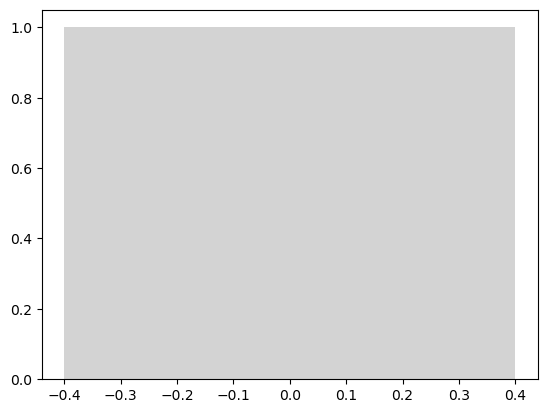

In [81]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


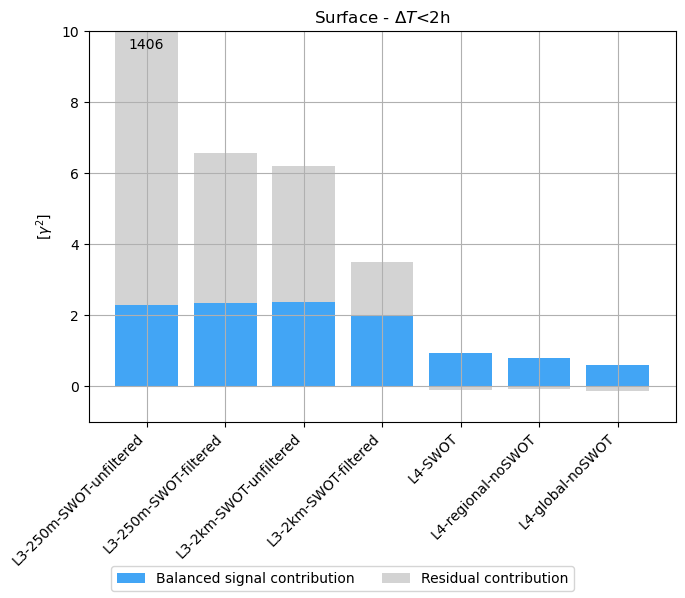

In [83]:
# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45, ha='right' )
ax.set_title(rf'Surface - $\Delta T$<{dt}h')
ax.set_ylim(-1,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


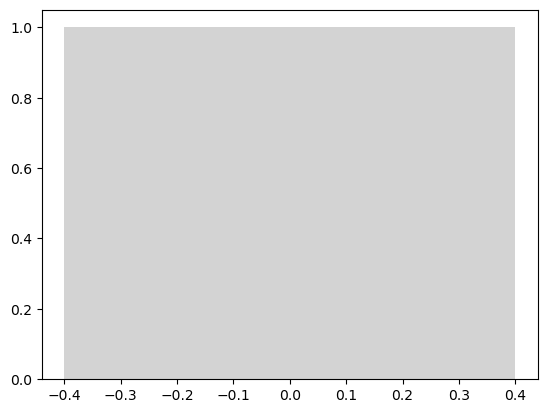

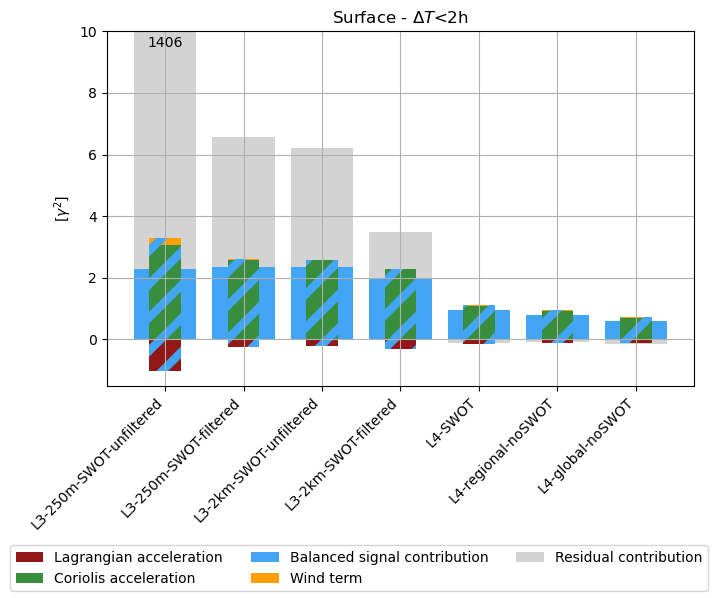

In [76]:
fig, ax=plt.subplots()
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45,ha='right' )
ax.set_title(rf'Surface - $\Delta T$<{dt}h')
ax.set_ylim(-1.5,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


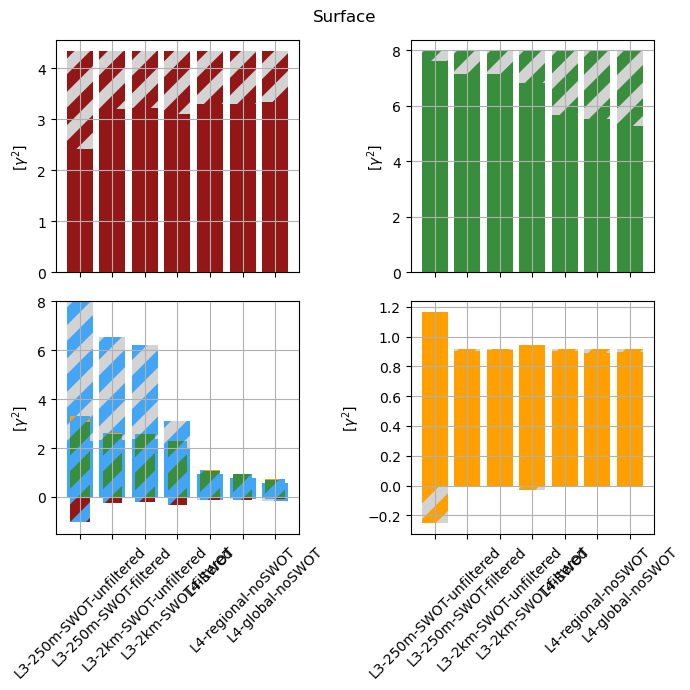

In [75]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )

axs[2].set_ylim(-1.5,8)
fig.suptitle('Surface')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))


# Depth =15m

In [13]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotregional', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4noswotglobal', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
             dict(drifter_key='nofilter', alti_key = 'L4withswot', wd_key = 'era5', ggd_var='adt', wd_depth='15'),
]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSD = DS.where(DS.depth==15, drop=True)


ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()

df['Pressure gradient'] = ['L3-250m-SWOT', 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]
df = df.reset_index().set_index('Pressure gradient')

nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
nofilter__L4noswotregional_adt__rio_15era5
nofilter__L4noswotglobal_adt__rio_15era5
nofilter__L4withswot_adt__rio_15era5
Identified SWOT and drifter outliers have been removed


5.853613642158059
5.989655275392735
7.106325885679414
7.324545165399574
4.820544871921339
4.978065903550418
5.885165190622785
6.091280991347079
4.0624746436547134
4.296435765472843
4.6595922159430385
4.7295215624503895
3.95764365224236
4.1788064502236795
4.444166981214774
4.494597347627956
4.151017721177442
4.382141328846164
4.759096474906246
4.863398630142633


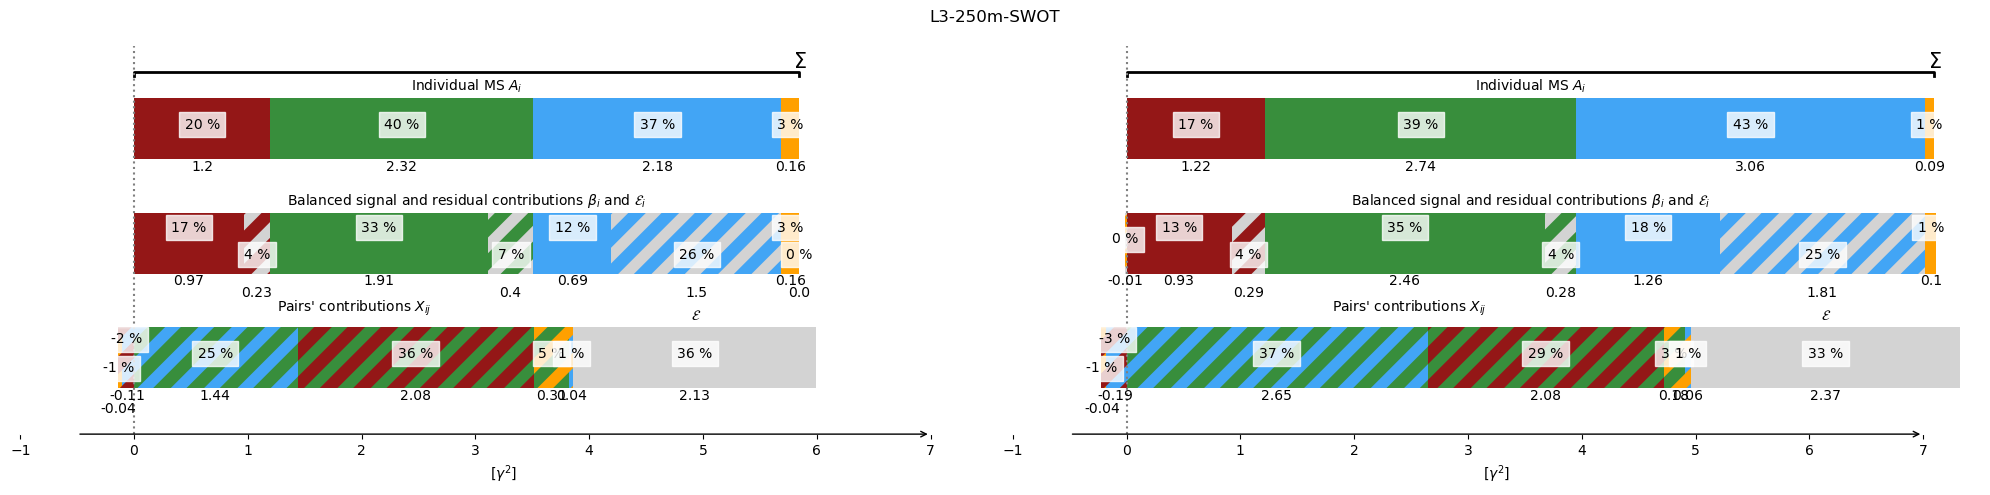

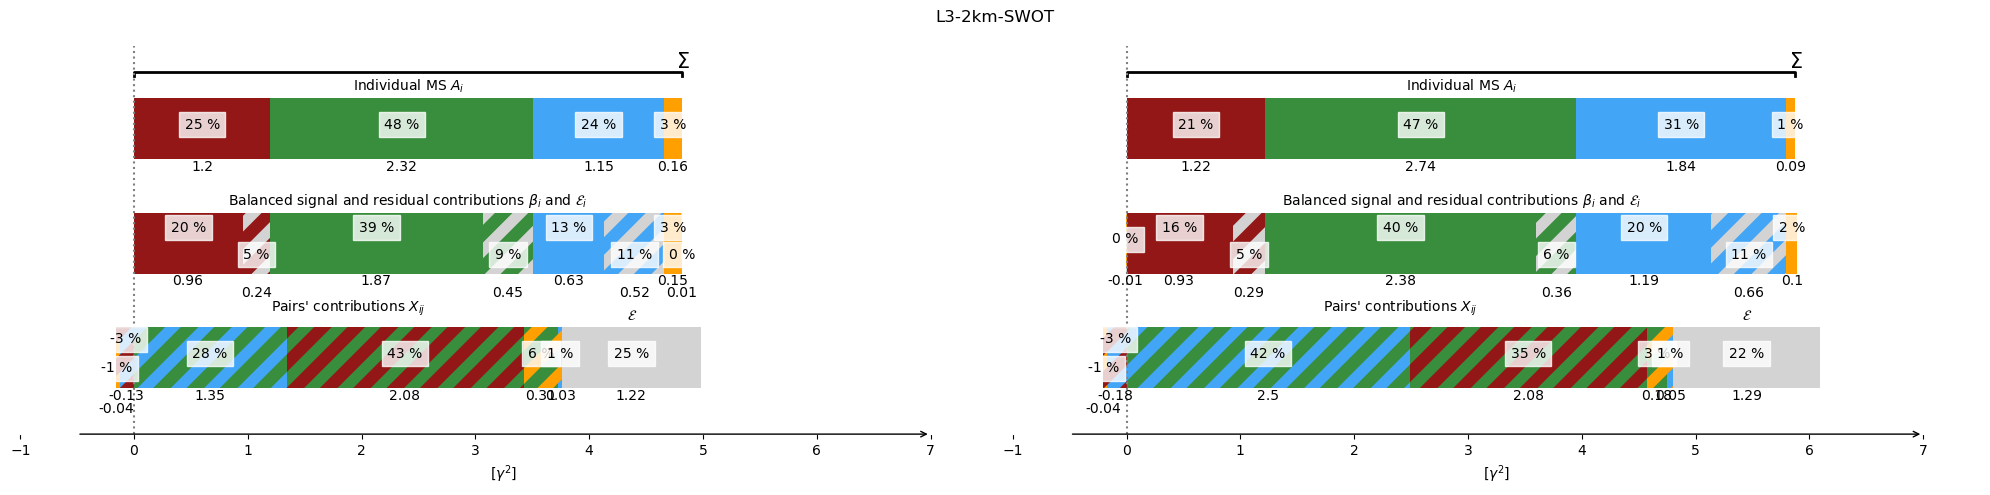

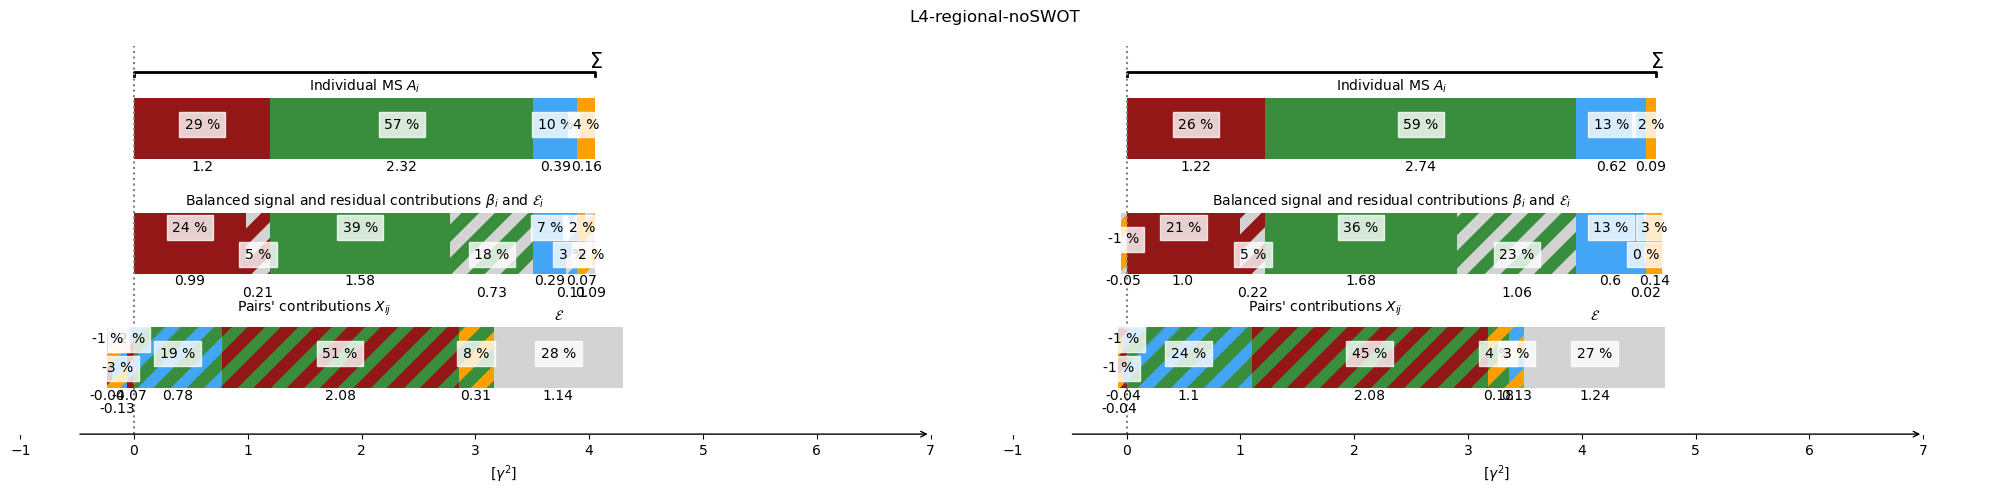

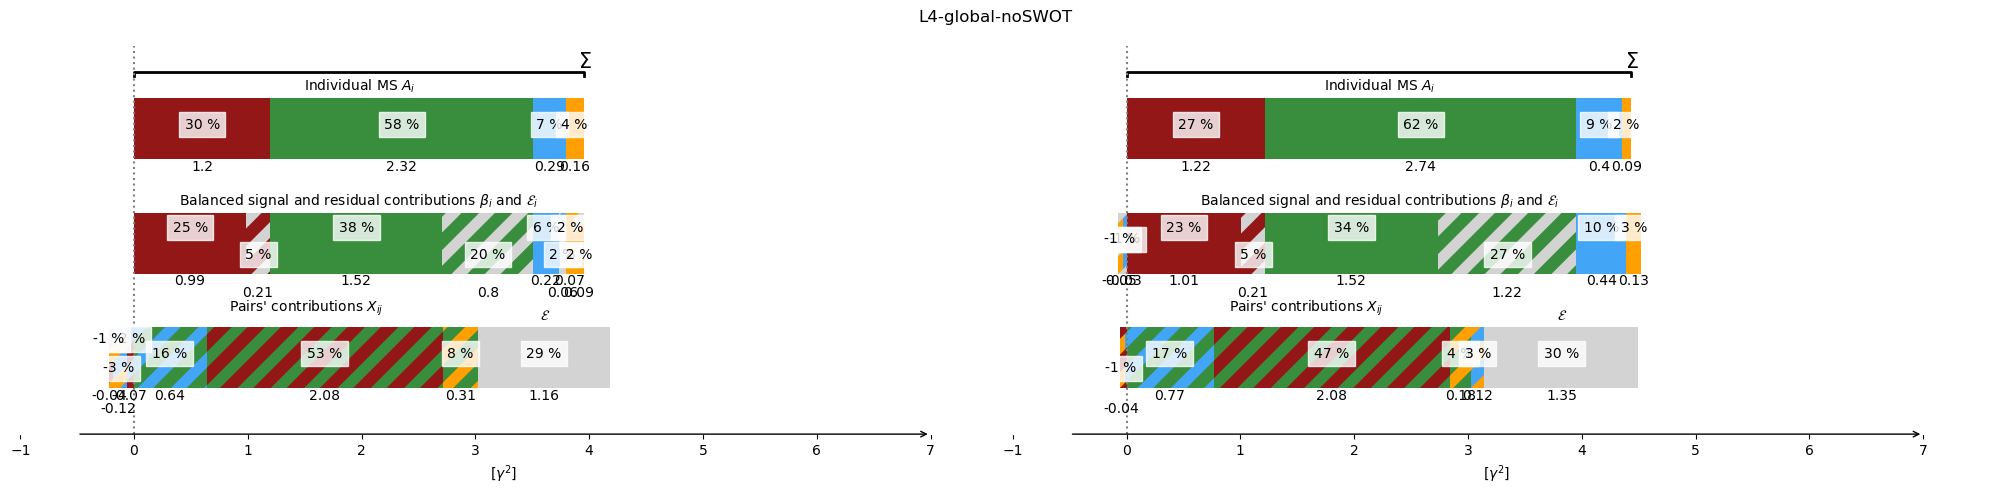

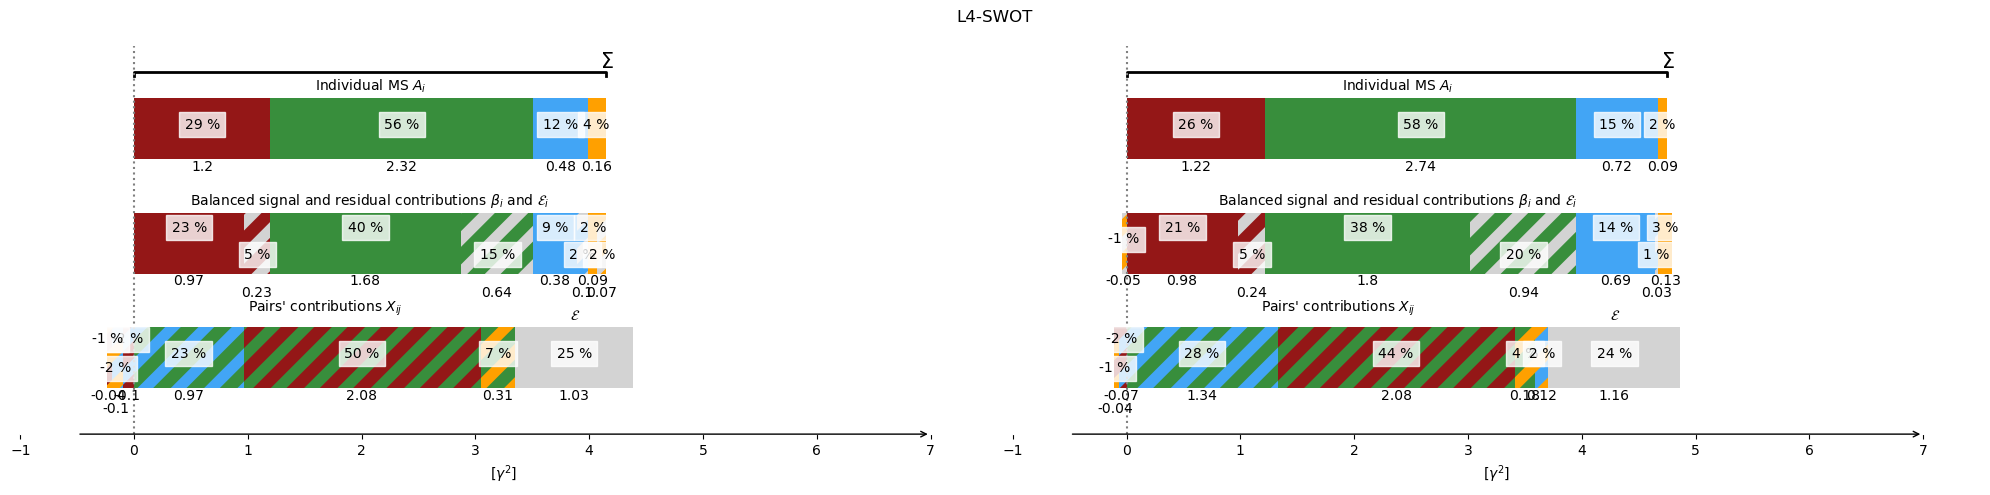

In [14]:
# Closure figs
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 7])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 7])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


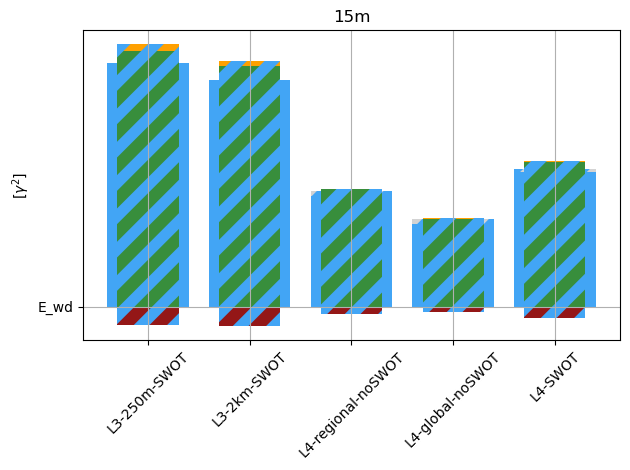

In [18]:
# Alti comparison
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(frameon=False)
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 8
    plt.rcParams["hatch.color"] = "lightgrey"
    if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_.B_ggd,color = c0['ggd'], hatch="/")
    else: ax.bar(i, ['E_'+vars[j]], color = c0['ggd'], hatch="/")
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )
ax.set_title('15m')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_15m_' + c + '.png'))
